# Ex.No.10 - K-Nearest Neighbours

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 07/04/2026_

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load Dataset
df = pd.read_csv(r"D:\VI\FOML\Datasets\penguins.csv")
print("Shape :", df.shape)

# Encode Target Column
le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])   # FEMALE / MALE

df.head()

Shape : (332, 5)


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181,3750,1
1,39.5,17.4,186,3800,0
2,40.3,18.0,195,3250,0
3,36.7,19.3,193,3450,0
4,39.3,20.6,190,3650,1


In [3]:
# Split Features and Target
X = df.drop("sex", axis=1)
y = df["sex"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

Train Shape : (265, 4)
Test Shape  : (67, 4)


In [4]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

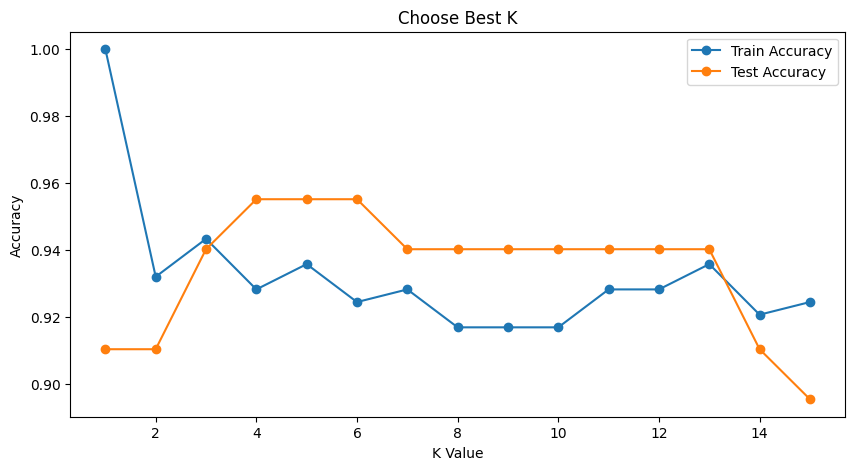

In [5]:
# Find Best K
train_scores = []
test_scores = []

for k in range(1,16):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(10,5))
plt.plot(range(1,16), train_scores, marker='o', label="Train Accuracy")
plt.plot(range(1,16), test_scores, marker='o', label="Test Accuracy")
plt.title("Choose Best K")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [6]:
# Train Final KNN Model
# Choose best K (example: 5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [7]:
# Prediction
y_train_pred = knn.predict(X_train_scaled)
y_test_pred  = knn.predict(X_test_scaled)

In [8]:
# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print("Train Accuracy :", round(train_acc*100,2), "%")
print("Test Accuracy  :", round(test_acc*100,2), "%")

Train Accuracy : 93.58 %
Test Accuracy  : 95.52 %


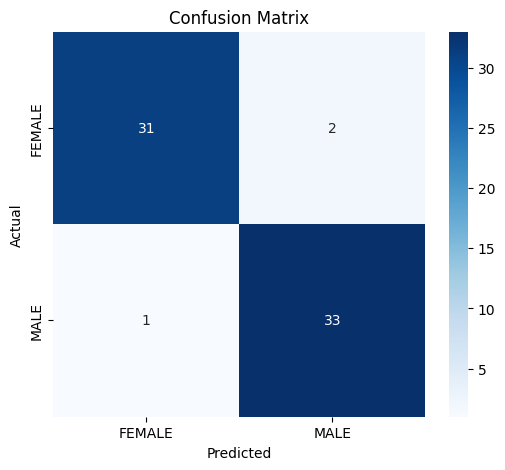

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

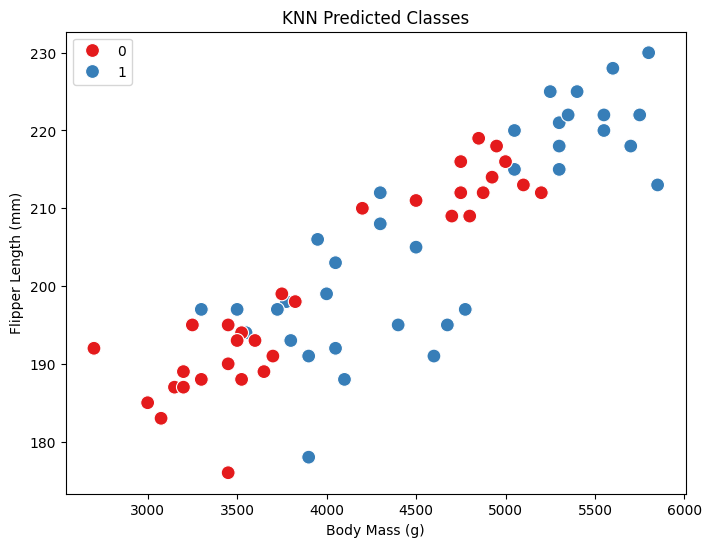

In [10]:
# Visualize Test Data Prediction
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_test["body_mass_g"],
    y=X_test["flipper_length_mm"],
    hue=y_test_pred,
    palette="Set1",
    s=100
)

plt.title("KNN Predicted Classes")
plt.xlabel("Body Mass (g)")
plt.ylabel("Flipper Length (mm)")
plt.show()

In [11]:
# Custom Data Prediction
custom_data = pd.DataFrame([{
    "culmen_length_mm":45.2,
    "culmen_depth_mm":17.1,
    "flipper_length_mm":200,
    "body_mass_g":5000
}])

custom_scaled = scaler.transform(custom_data)

pred = knn.predict(custom_scaled)[0]

print("Predicted Sex :", le.inverse_transform([pred])[0])

Predicted Sex : MALE


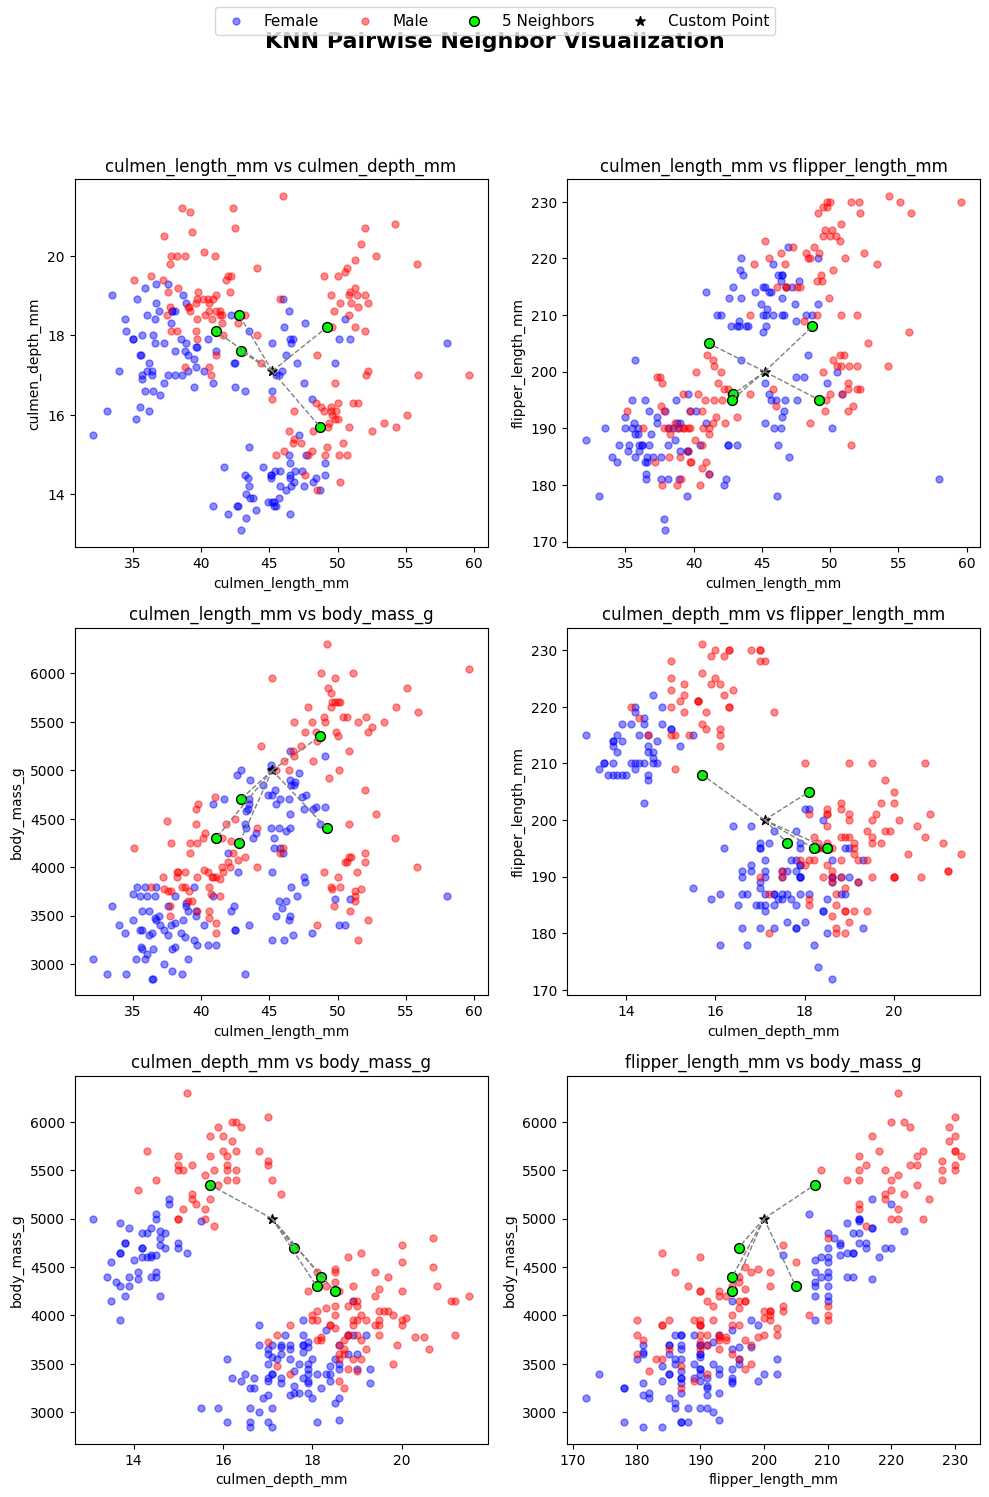

In [12]:
# Find 5 nearest neighbors
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_train_scaled)
distances, indices = nn.kneighbors(custom_scaled)

# Convert scaled data back
train_original = scaler.inverse_transform(X_train_scaled)
custom_original = scaler.inverse_transform(custom_scaled)

# Feature names
features = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

pairs = list(combinations(range(4), 2))

# Create 6 subplots
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
axes = axes.flatten()

male_mask = (y_train.values == le.transform(["MALE"])[0])
female_mask = (y_train.values == le.transform(["FEMALE"])[0])

for plot_id, (i, j) in enumerate(pairs):

    ax = axes[plot_id]

    # Female points
    ax.scatter(
        train_original[female_mask, i],
        train_original[female_mask, j],
        c='blue',
        alpha=0.45,
        s=25,
        label="Female" if plot_id == 0 else ""
    )

    # Male points
    ax.scatter(
        train_original[male_mask, i],
        train_original[male_mask, j],
        c='red',
        alpha=0.45,
        s=25,
        label="Male" if plot_id == 0 else ""
    )

    # Nearest neighbors
    ax.scatter(
        train_original[indices[0], i],
        train_original[indices[0], j],
        c='lime',
        s=50,
        edgecolors='black',
        label="5 Neighbors" if plot_id == 0 else ""
    )

    # Custom point
    ax.scatter(
        custom_original[:, i],
        custom_original[:, j],
        c='black',
        marker='*',
        s=50,
        label="Custom Point" if plot_id == 0 else ""
    )

    # Lines to neighbors
    for idx in indices[0]:
        ax.plot(
            [custom_original[0, i], train_original[idx, i]],
            [custom_original[0, j], train_original[idx, j]],
            '--',
            color='gray',
            linewidth=1
        )

    ax.set_title(f"{features[i]} vs {features[j]}")
    ax.set_xlabel(features[i])
    ax.set_ylabel(features[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=11)

plt.suptitle("KNN Pairwise Neighbor Visualization", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()